**NOTA:**

Artur:

1.análise do conjunto de dados e sua breve descrição  ✅

5.análise preditiva/ aprendizagem de máquina (classificação ou regressão conforme apropriado), comparando o desempenho de vários modelos

Maria:

2.tarefas de pré-processamento dos dados (se julgar necessárias) ✅

6.seleção/ importância das variáveis usadas pelos modelos

Catarina:

3.sumarização dos dados (estatística descritiva, exploração com recurso a gráficos) ✅

4.análise estatística multivariada (não supervisionada): clustering, redução de dimensionalidade/ visualização ✅

# **Practical Assignment 2 – Python Application**

# 1. Analysis of the dataset and its brief description

## 1.1 Introduction
The goal of this practical assignment is to apply data analysis and knowledge extraction techniques to biological data, with a focus on predicting the mutagenicity of chemical compounds. The task involves developing a complete pipeline in Python, including data loading, preprocessing, exploratory analysis, predictive modeling, and performance evaluation.

The dataset used corresponds to the Ames test, a widely adopted biological assay for identifying compounds with mutagenic potential. It includes a matrix of numerical molecular descriptors (features) and a binary label indicating whether each compound is **mutagenic** `(1)` or **not** `(0)`.

This work provides an opportunity to apply several concepts covered throughout the semester, including multivariate analysis, supervised learning, feature selection, and data visualization.

## **Imports**

In [1]:
# Core Libraries
import os
import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Model Training and Evaluation
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report, 
    roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.feature_selection import (
    SelectFromModel, SelectKBest, VarianceThreshold, f_classif
)
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, TransformerMixin

# Optional: Dimensionality Reduction and Clustering 
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

# Optional: Synthetic Data Generation
from sklearn.datasets import make_classification

# Optional: Robust statistical tools
from scipy.stats import mstats


## 1.2 Assigment Context - Ames Mutagenicity

### Dataset Description: 

Mutagenicity means the ability of a drug to induce genetic alterations. Drugs that can cause damage to the DNA can result in cell death or other severe adverse effects. Nowadays, the most widely used assay for testing the mutagenicity of compounds is the Ames experiment which was invented by a professor named Ames. The Ames test is a short-term bacterial reverse mutation assay detecting a large number of compounds which can induce genetic damage and frameshift mutations. The dataset is aggregated from four papers.

### Task Description: 

Binary classification. Given a drug SMILES string, predict whether it is mutagenic `(1)` or not mutagenic `(0)`.

## 1.3 Data Exploration with Python

In [2]:
# Load the features dataset
if os.path.exists("/home/arog"):
    features_path = "data_csv/ames_features.csv"
else:
    features_path = "data_csv\\ames_features.csv"

features_df = pd.read_csv(features_path)

# Basic dataset information
features_info = {
    "Shape": features_df.shape,
    "Columns": features_df.columns.tolist(),
    "Missing Values": features_df.isnull().sum().sum(),
    "Preview": features_df.head()
}

print("Dataset Shape:")
pprint.pprint(features_info["Shape"])

Dataset Shape:
(7273, 208)


In [3]:
print("\n Feature Columns (truncated list):")
pprint.pprint(features_info["Columns"])


 Feature Columns (truncated list):
['MaxEStateIndex',
 'MinEStateIndex',
 'MaxAbsEStateIndex',
 'MinAbsEStateIndex',
 'qed',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA3',
 'SMR_VSA4',
 'SMR_VSA

In [4]:
print("Total Missing Values:")
print(features_info["Missing Values"])

Total Missing Values:
0


In [5]:
print("Dataset Preview (first 5 rows):")
features_info["Preview"]

Dataset Preview (first 5 rows):


,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.663401,-0.396099,11.663401,0.008895,0.181963,342.310,332.230,342.06406,124.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,11.824743,-0.170602,11.824743,0.170602,0.269289,301.345,286.225,301.11030,112.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,14.431072,-0.378575,14.431072,0.128988,0.184582,646.614,628.470,646.11650,232.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,10.422196,-0.670278,10.422196,0.248657,0.103849,157.133,150.077,157.05997,60.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10.521759,-0.752407,10.521759,0.278148,0.342148,138.086,136.070,138.01778,50.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### **Output**

In [6]:
# Load the features dataset
outputs_path = "data_csv/ames_outputs.csv"
outputs_df = pd.read_csv(outputs_path)

# Basic dataset information
outputs_info = {
    "Shape": outputs_df.shape,
    "Columns": outputs_df.columns.tolist(),
    "Missing Values": outputs_df.isnull().sum().sum(),
    "Preview": outputs_df.head(),
    "Class Distribution": outputs_df['Y'].value_counts().to_dict()
}

print("Dataset Shape:")
pprint.pprint(outputs_info["Shape"])

Dataset Shape:
(7273, 3)


In [7]:
print("Feature Columns (truncated list):")
pprint.pprint(outputs_info["Columns"])

Feature Columns (truncated list):
['ids', 'smiles', 'Y']


In [8]:
print("Total Missing Values:")
print(outputs_info["Missing Values"])

Total Missing Values:
0


In [9]:
print("Dataset Preview (first 5 rows):")
outputs_info["Preview"]

Dataset Preview (first 5 rows):


,ids,smiles,Y
0,Drug 0,O=[N+]([O-])c1ccc2ccc3ccc([N+](=O)[O-])c4c5ccc...,1
1,Drug 1,O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2,1
2,Drug 2,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...,0
3,Drug 3,[N-]=[N+]=CC(=O)NCC(=O)NN,1
4,Drug 4,[N-]=[N+]=C1C=NC(=O)NC1=O,1


In [10]:
print("Class Distribution — 1 = mutagenic, 0 = non-mutagenic:")
pprint.pprint(outputs_info["Class Distribution"])

Class Distribution — 1 = mutagenic, 0 = non-mutagenic:
{0: 3299, 1: 3974}


## 1.4 Datasets Overview

This project utilizes two datasets derived from the Ames mutagenicity test: one containing molecular features extracted from chemical structures, and another providing binary mutagenicity classification labels.

---

### Dataset Features

This dataset includes computed molecular descriptors and fragment-based features for each compound, derived from its SMILES (Simplified Molecular Input Line Entry System) representation.

- **Rows (samples)**: 7,273 compounds  
- **Columns (features)**: 208 numerical descriptors  
- **Types of features**:
  - *Physicochemical*: `MolWt`, `TPSA`, `LogP`, `qed`, etc.
  - *Topological and electronic*: `Chi`, `BalabanJ`, `EState`, etc.
  - *Structural fragments (binary flags)*: `fr_nitro`, `fr_urea`, `fr_halogen`, etc.

The dataset contains no missing values and is ready for use in machine learning tasks.

---

### Dataset Output

This dataset contains binary classification labels indicating the mutagenicity of each compound, aligned with the compounds in the feature dataset.

- **Rows**: 7,273 (one per compound)
- **Columns**:
  - `ids`: Unique compound identifier
  - `smiles`: SMILES representation of the compound
  - `Y`: Binary label for mutagenicity  
    - `1` = Mutagenic  
    - `0` = Non-mutagenic

#### Class Distribution

| Label             | Count |
|-------------------|--------|
| Mutagenic (1)     | 3,974  |
| Non-mutagenic (0) | 3,299  |

There are no missing values in the output dataset. The class distribution is slightly imbalanced, with more mutagenic than non-mutagenic samples.

---

Together, these datasets form a complete and clean structure for building supervised learning models to predict the mutagenic potential of chemical compounds.


# 2. Data preprocessing tasks

Before fitting any predictive model, we apply a systematic sequence of preprocessing steps to the feature dataset. These steps ensure that the data are clean, consistent, and appropriately scaled for machine learning algorithms.

No missing values were detected in the feature dataset. Therefore, no imputation or NA-specific preprocessing was required.  

In this section, we cover the following stages:

**1. Outlier Handling**

Reduce the influence of rare, extreme measurements.

**2. Low-Variance Feature Filtering**

Drop near-constant descriptors that carry little predictive information.

## 2.1 Outlier Handling - Univariate Outlier Detection Across All Features

To identify how many values lie outside the 1st and 99th percentiles for each descriptor, we:

1. **Compute the percentile thresholds**  
   - `q_low` stores the 1st percentile of every column  
   - `q_high` stores the 99th percentile of every column

2. **Count outliers per feature**  
   - We flag values below `q_low` or above `q_high` in each column  
   - Summarize both the raw counts and percentages of outliers

In [11]:
# Compute per-column percentiles
q_low  = features_df.quantile(0.01)
q_high = features_df.quantile(0.99)

# Count outliers per column
outlier_counts = ((features_df < q_low) | (features_df > q_high)).sum()
outlier_pct    = outlier_counts / len(features_df) * 100

print("Outliers per feature (count, %):")
print(pd.DataFrame({
    'count': outlier_counts,
    'percent': outlier_pct.round(2)
}))


Outliers per feature (count, %):
                   count  percent
MaxEStateIndex       146     2.01
MinEStateIndex       146     2.01
MaxAbsEStateIndex    146     2.01
MinAbsEStateIndex    144     1.98
qed                  146     2.01
...                  ...      ...
fr_thiazole            4     0.05
fr_thiocyan            3     0.04
fr_thiophene          58     0.80
fr_unbrch_alkane      65     0.89
fr_urea                6     0.08

[208 rows x 2 columns]


Capping these extreme tails helps stabilize models that are sensitive to range and variance, while retaining all samples.

*Why Winsorization?*
- Winsorization limits extreme values by “clamping” them at specified percentile cut-offs rather than dropping rows.
- For each column, values below the lower percentile are set to that percentile value, and values above the upper percentile are set to the upper bound.

`(0.01, 0.01)`

We measured the 1st and 99th percentiles for each feature and found about 1–2 % of observations lie outside those bounds.
Using limits=(0.01, 0.01) directly matches that analysis, ensuring we only clamp the most extreme ~1 % on each tail.

By integrating this `Winsorizer(limits=(0.01, 0.01))` at the start of our preprocessing pipeline, we ensure each descriptor’s most extreme values are tamed in a principled, reproducible way—providing robust inputs for subsequent power-transformation, scaling, and modeling.

In [12]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits
    def fit(self, features_df, y=None):
        return self
    def transform(self, features_df):
        features_df_arr = np.asarray(features_df, dtype=float)
        return np.apply_along_axis(lambda col: mstats.winsorize(col, limits=self.limits), 0, features_df_arr)

## 2.2 Low-Variance Feauture Filtering

The `VarianceThreshold` transformer removes any feature whose variance does not exceed the specified threshold. Features with very low variance (i.e., nearly constant across samples) carry little to no predictive information and can be safely dropped.

In [13]:
var_filt = VarianceThreshold(threshold=0.01)
var_filt

VarianceThreshold(threshold=0.01)

# 3. Data Summarization

In [14]:
# Apply winsorization to the variance-filtered data
winsor = Winsorizer(limits=(0.01, 0.01))
X_winsor = winsor.fit_transform(features_df)

# Reconstruct the DataFrame with same column names
X_winsor_df = pd.DataFrame(X_winsor, columns=features_df.columns)
X_winsor_df['Mutagenic'] = outputs_df['Y'].values

# Use this updated DataFrame for all of Point 3
df = X_winsor_df

## 3.1 Summary statistics

In [15]:
print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,Mutagenic
count,7273.000000,7273.000000,7273.000000,7273.000000,7273.000000,7273.000000,7273.000000,7273.000000,7273.000000,7273.0,...,7273.000000,7273.0,7273.0,7273.0,7273.000000,7273.0,7273.0,7273.000000,7273.000000,7273.000000
mean,9.356021,-0.449194,9.356021,0.340727,0.510291,241.969826,228.382367,241.606120,87.885192,0.0,...,0.010587,0.0,0.0,0.0,0.011687,0.0,0.0,0.224942,0.017049,0.546405
std,3.014129,1.205136,3.014129,0.346898,0.165930,104.710018,99.332807,104.552023,38.672038,0.0,...,0.102355,0.0,0.0,0.0,0.107481,0.0,0.0,1.083428,0.129464,0.497876
min,2.231806,-4.658179,2.231806,0.003087,0.124224,70.091000,62.051000,69.937706,24.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
25%,6.209384,-0.846972,6.209384,0.075424,0.396894,165.148000,156.100000,165.039000,60.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
50%,10.384028,-0.355799,10.384028,0.211296,0.510491,230.270000,218.173000,230.069140,84.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,1.000000
75%,11.488809,0.353001,11.488809,0.510718,0.621552,296.319000,280.241000,296.060400,108.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,1.000000
max,13.697634,1.333333,13.697634,1.430556,0.870769,620.735000,580.426000,620.118160,230.000000,0.0,...,1.000000,0.0,0.0,0.0,1.000000,0.0,0.0,8.000000,1.000000,1.000000


> The dataset contains 7,273 compounds and 208 numerical molecular descriptors. After pre-processing, all features are complete and show consistent ranges. Core descriptors such as `MolWt`, `qed`, and `NumValenceElectrons` present substantial variability, while fragment-based features remain sparse and mostly binary. The data is well-structured for further analysis.


## 3.2 Target variable distribution

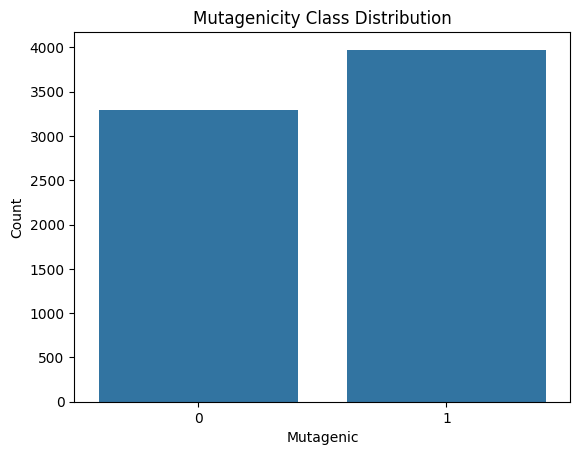

In [16]:
sns.countplot(x='Mutagenic', data=df)
plt.title("Mutagenicity Class Distribution")
plt.xlabel("Mutagenic")
plt.ylabel("Count")
plt.show()

> The `Mutagenic` target variable has slightly more positive (mutagenic) samples than negative ones. This distribution is suitable for classification tasks without requiring strong resampling techniques. The class proportions are close enough to avoid major bias during model training.


## 3.3 Feature distributions by variance

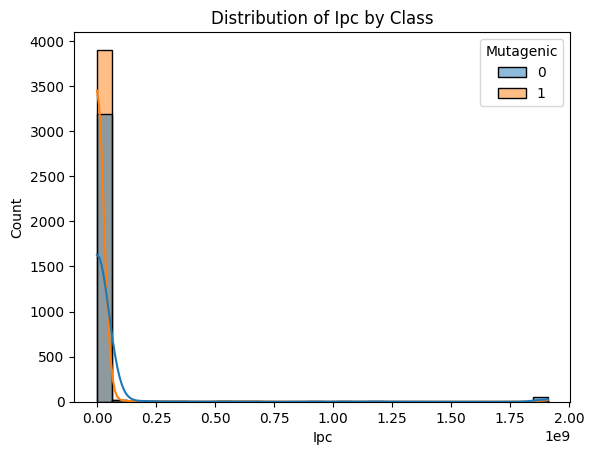

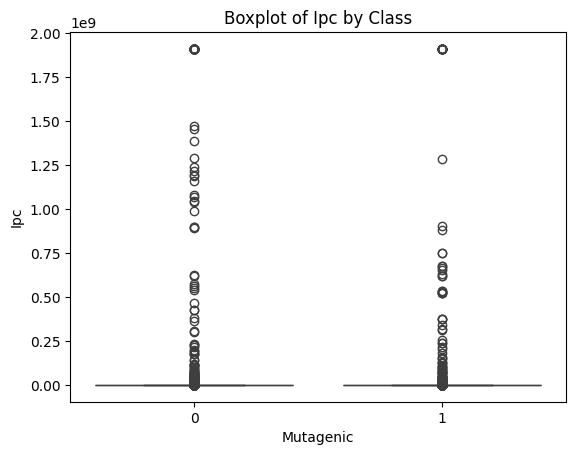

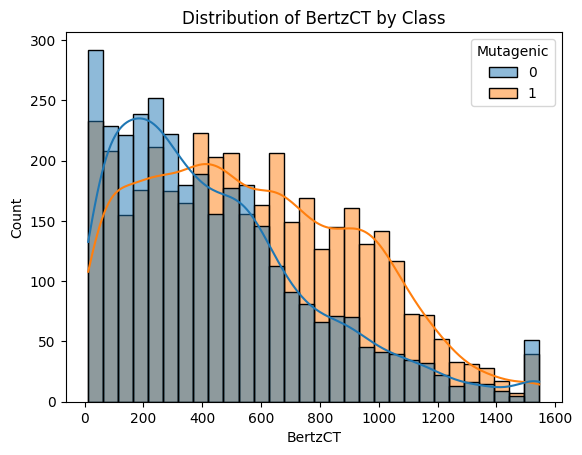

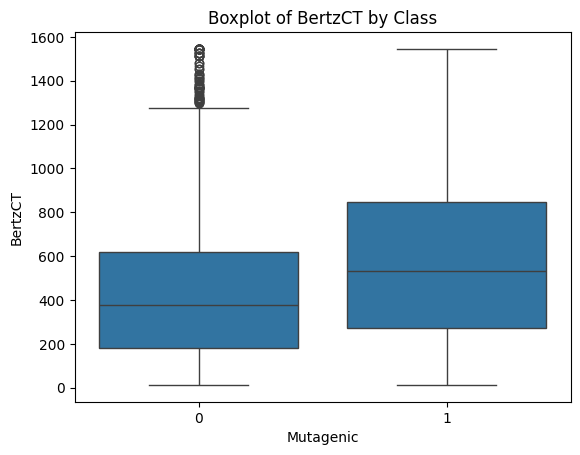

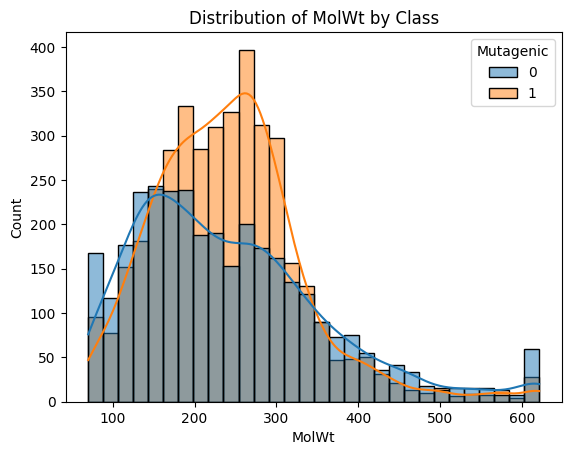

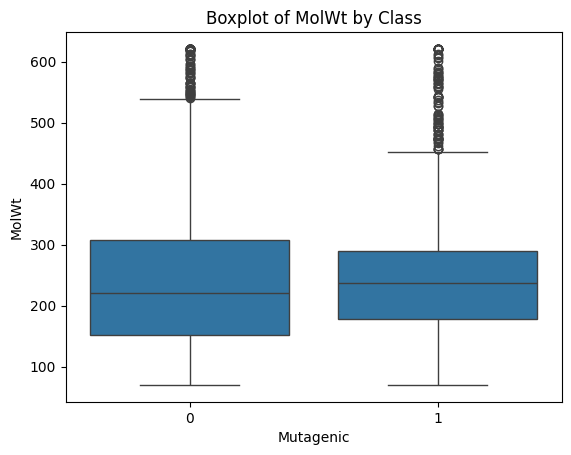

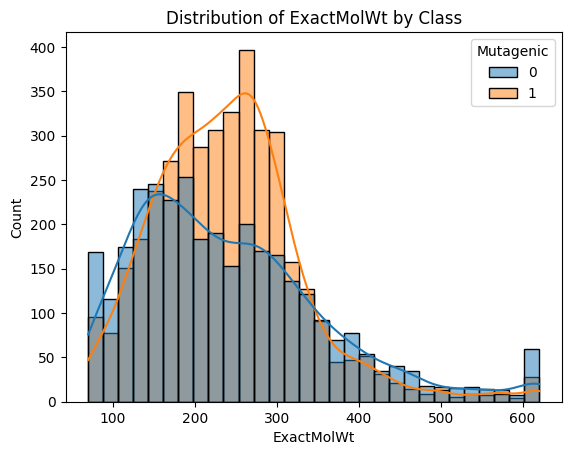

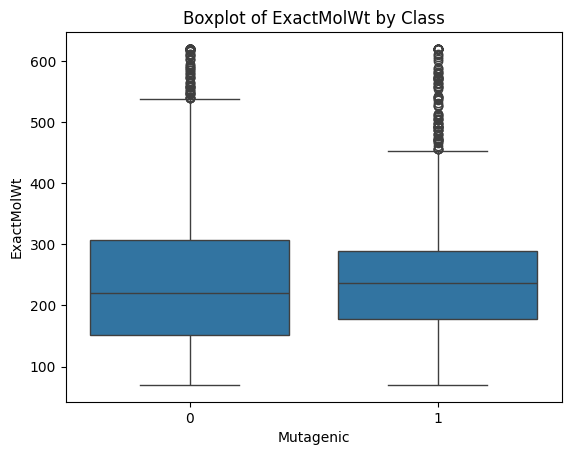

In [17]:
variances = df.drop(columns='Mutagenic').var()
top_features = variances.sort_values(ascending=False).head(4).index

# Visual inspection of key features
for feat in top_features:
    sns.histplot(data=df, x=feat, hue='Mutagenic', kde=True, bins=30)
    plt.title(f"Distribution of {feat} by Class")
    plt.show()

    sns.boxplot(x='Mutagenic', y=feat, data=df)
    plt.title(f"Boxplot of {feat} by Class")
    plt.show()

> Several molecular descriptors show different distribution patterns between mutagenic and non-mutagenic compounds:
>
>* **Ipc** is extremely right-skewed for both classes, with most values concentrated near zero and a few very large outliers. The boxplot confirms this with long upper whiskers and numerous extreme values, even after winsorization.
>* **BertzCT** displays a visible shift in distribution: mutagenic compounds tend to have higher complexity scores, with the median and upper quartile notably higher than in the non-mutagenic group.
>* **MolWt** and **ExactMolWt** also tend to be slightly higher for mutagenic compounds, though the overlap is substantial. Both descriptors show moderate right-skew and many outliers above \~500 Da.
>
>These patterns suggest that higher molecular weight and structural complexity may be associated with mutagenicity, while some descriptors (e.g., Ipc) may be dominated by a small number of extreme values.


## 3.4 Correlation matrix heatmap

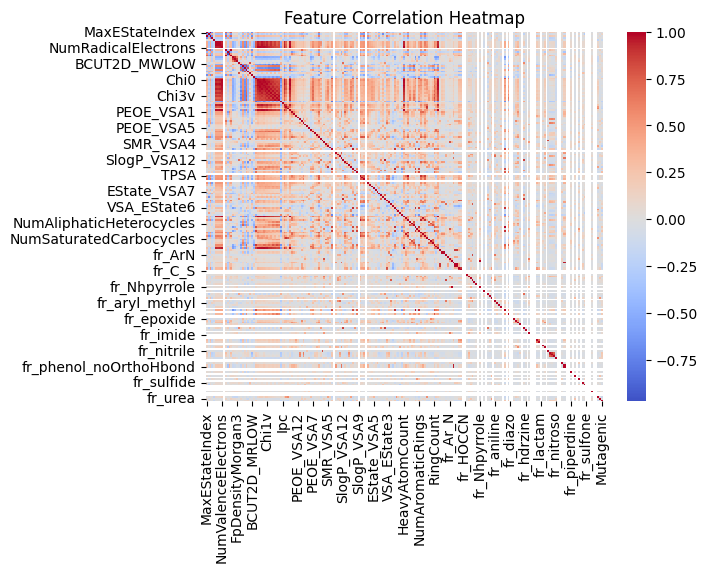

In [18]:
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

>The correlation heatmap reveals several strong linear relationships among descriptors. In particular:
>
>* **Highly correlated groups** are visible among related descriptors, such as EState and VSA variants, which often capture overlapping structural properties.
>* **Fragment-based features** (e.g., `fr_aromatic`, `fr_nitro`) show weak to moderate correlation with other features and with `Mutagenic`, suggesting they may carry complementary signal.
>* The variable `Mutagenic` appears only weakly correlated with most individual features, indicating that mutagenicity likely depends on **nonlinear combinations** of descriptors — supporting the use of machine learning for classification.
>
>This structure reinforces the importance of dimensionality reduction and multivariate models for downstream analysis.


# 4. Multivariate statistical analysis (unsupervised)

## 4.1 Normalize features

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_winsor)

## 4.2 PCA projection

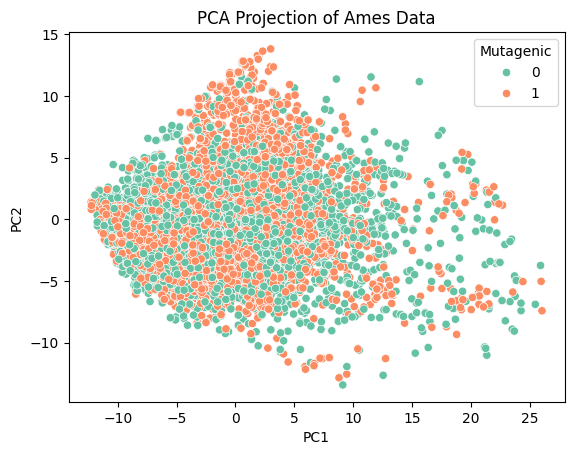

In [20]:
pca = PCA(n_components=2)
pca_proj = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_proj, columns=['PC1', 'PC2'])
pca_df['Mutagenic'] = outputs_df["Y"].values

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Mutagenic', palette='Set2')
plt.title("PCA Projection of Ames Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()










The PCA projection onto the first two components shows that mutagenic and non-mutagenic compounds partially overlap, with no clear linear separation. However, subtle clustering tendencies and structural gradients are visible, suggesting that mutagenicity may be influenced by complex, multivariate interactions across descriptors. PCA successfully reduces dimensionality while retaining variation, providing a solid base for further unsupervised exploration.



## 4.3 t-SNE projection

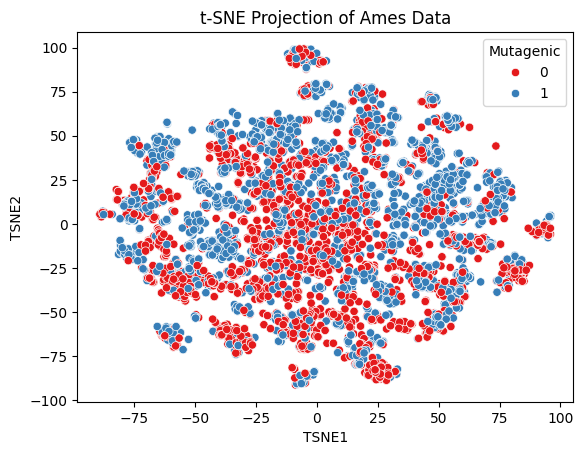

In [21]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_proj = tsne.fit_transform(X_scaled)
tsne_df = pd.DataFrame(tsne_proj, columns=['TSNE1', 'TSNE2'])
tsne_df['Mutagenic'] = outputs_df["Y"].values

sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Mutagenic', palette='Set1')
plt.title("t-SNE Projection of Ames Data")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.show()

>The t-SNE projection highlights local structures in the dataset, forming visually distinct clusters. However, mutagenic and non-mutagenic compounds remain largely intermixed across the 2D space. This suggests that while some localized patterns exist, mutagenicity is not easily separable via low-dimensional projections. Nonlinear interactions among descriptors likely drive the classification boundary.

## 4.4 KMeans clustering

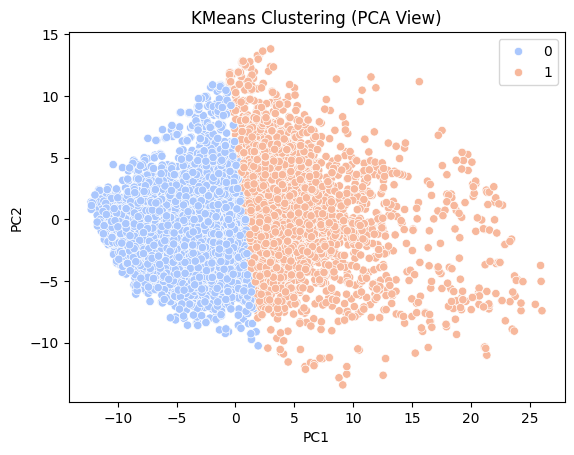

In [22]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=pca_proj[:, 0], y=pca_proj[:, 1], hue=clusters, palette='coolwarm')
plt.title("KMeans Clustering (PCA View)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

>KMeans clustering with two clusters shows a clean partition in PCA space, forming two dense and compact groups. While the clustering does not use the `Mutagenic` labels, the result aligns moderately with the data structure, indicating that unsupervised grouping captures meaningful variance in the descriptors. This suggests potential for separating mutagenic profiles based on chemical features alone, although overlap remains.



## 4.5 Hierarchical clustering (dendrogram)

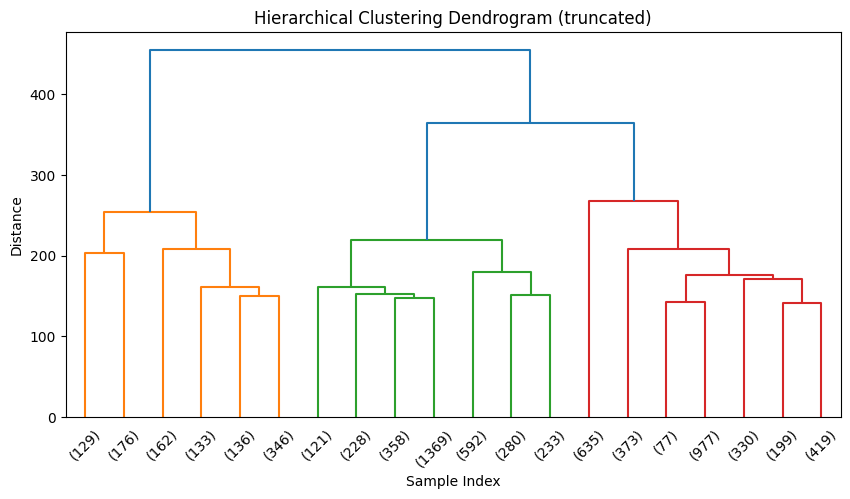

In [23]:
linkage_matrix = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=20, leaf_rotation=45., leaf_font_size=10.)
plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

>The dendrogram reveals a hierarchical grouping of samples based on molecular descriptor similarity. Clear substructures emerge at various distances, indicating regions of higher local similarity in the descriptor space. However, since the clustering is unsupervised and the leaves are not annotated by `Mutagenic`, no biological interpretation can be made without further label-based analysis. The truncation provides a compact overview of representative sample clusters, suitable for initial exploration of chemical diversity.



### **Conclusion of Unsupervised Analysis**

Dimensionality reduction (PCA, t-SNE) and clustering (KMeans, hierarchical) allowed the visualization and grouping of structurally similar compounds. While some separability and local patterns emerged, unsupervised methods alone did not reveal a clear distinction between mutagenic and non-mutagenic compounds. This reinforces the need for supervised learning methods capable of modeling more complex, nonlinear relationships in the data.



Given the limited interpretability of class separation in the unsupervised setting, the next step is to apply supervised machine learning algorithms. These models will learn to predict mutagenicity from molecular descriptors using known labeled data, enabling evaluation of predictive power and variable importance.



# 5. Supervised ML

## Code - Random Forest and SVM for Binary Classification

The pipeline includes the following stages:
1. **Data preparation** – loading, cleaning, and splitting the dataset.
2. **Feature selection** – identifying statistically significant and model-relevant features.
3. **Model training with hyperparameter tuning** – optimizing both Random Forest and SVM classifiers using cross-validated grid search.
4. **Model evaluation** – assessing performance using classification metrics and validation curves.
5. **Feature importance analysis** – interpreting the most influential molecular descriptors using permutation importance.


### 1. Data Loading and Preparation (Comment/Uncomment for pipeline testing)

In [24]:
RANDOM_STATE = 123456
np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8')

# Load your data (replace with your actual data loading)
X = features_df
y = outputs_df['Y']

# Create synthetic data for pipline testing (comment if trying real data)
# X, y = make_classification(n_samples=1000, n_features=208, n_informative=50, 
#                           n_redundant=30, random_state=RANDOM_STATE)

# X = pd.DataFrame(X, columns=features_df.columns[:208])  # reuse real names if count matches
# y = pd.Series(y, name='target')

### 2. Exploratory Data Analysis

Features shape: (7273, 208)
Target distribution:
Y
1    0.546405
0    0.453595
Name: proportion, dtype: float64


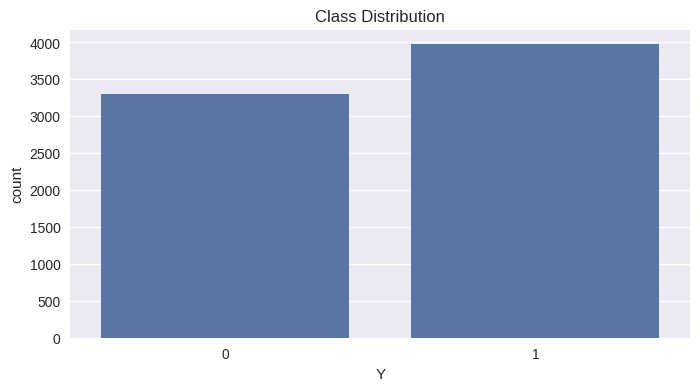

In [25]:
# Basic info
print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

# Visualize distribution
plt.figure(figsize=(8, 4))
sns.countplot(x=y)
plt.title('Class Distribution')
plt.show()

In [26]:
# Get both F-scores and p-values
f_scores, p_values = f_classif(X, y)

# Combine into a DataFrame
f_df = pd.DataFrame({
    'F-score': f_scores,
    'p-value': p_values
}, index=X.columns)

# Sort by p-value (ascending = most significant)
f_df_sorted = f_df.sort_values(by='p-value')

# Show top 10 most significant features
f_df_sorted.head(20)

/home/arog/miniconda3/envs/global/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 67  80 195] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/arog/miniconda3/envs/global/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,F-score,p-value
SlogP_VSA8,643.302936,4.588876e-136
NumAromaticRings,452.479749,1.851773e-97
SMR_VSA5,444.207055,9.191823e-96
NumAromaticCarbocycles,397.400010,3.927734e-86
fr_benzene,397.179837,4.361023e-86
fr_nitro,373.636980,3.214033e-81
SlogP_VSA5,339.640607,3.662261e-74
HallKierAlpha,303.282549,1.405846e-66
VSA_EState8,289.922838,8.802282e-64
RingCount,287.510813,2.818960e-63


### 3. Train-Test Split and Univariate Feature Selection

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size: {X_test.shape[0]} samples\n")

#Confirm class distribution in each subset
print("Full dataset class distribution:")
print(y.value_counts(normalize=True).rename_axis('Class').reset_index(name='Proportion'))

print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True).rename_axis('Class').reset_index(name='Proportion'))

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True).rename_axis('Class').reset_index(name='Proportion'))

Train size: 5818 samples
Test size: 1455 samples

Full dataset class distribution:
   Class  Proportion
0      1    0.546405
1      0    0.453595

Training set class distribution:
   Class  Proportion
0      1    0.546408
1      0    0.453592

Test set class distribution:
   Class  Proportion
0      1    0.546392
1      0    0.453608


In [28]:
# Step 1 – Compute F-scores and p-values from training data
f_scores, p_values = f_classif(X_train, y_train)

# Step 2 – Create mask for p-values < 0.05
significant_mask = p_values < 0.01

# Step 3 – Manually apply the mask
X_train = X_train.loc[:, significant_mask]
X_test = X_test.loc[:, significant_mask]

# (Optional) keep feature names consistent with the mask
selected_features = X_train.columns
print(f"Selected {len(selected_features)} features with p < 0.01")

Selected 113 features with p < 0.01


/home/arog/miniconda3/envs/global/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  9  67  80 195] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/arog/miniconda3/envs/global/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


### 4. Feature Scaling

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5. Feature Selection

In [30]:
#SelectFromModel 
selector = SelectFromModel(
    RandomForestClassifier(random_state=RANDOM_STATE),
    threshold="1.5*median"
)
selector.fit(X_train_scaled, y_train)

X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

print(f"Original features: {X_train.shape[1]}")
print(f"Selected features (SelectFromModel): {X_train_selected.shape[1]}")

Original features: 113
Selected features (SelectFromModel): 38


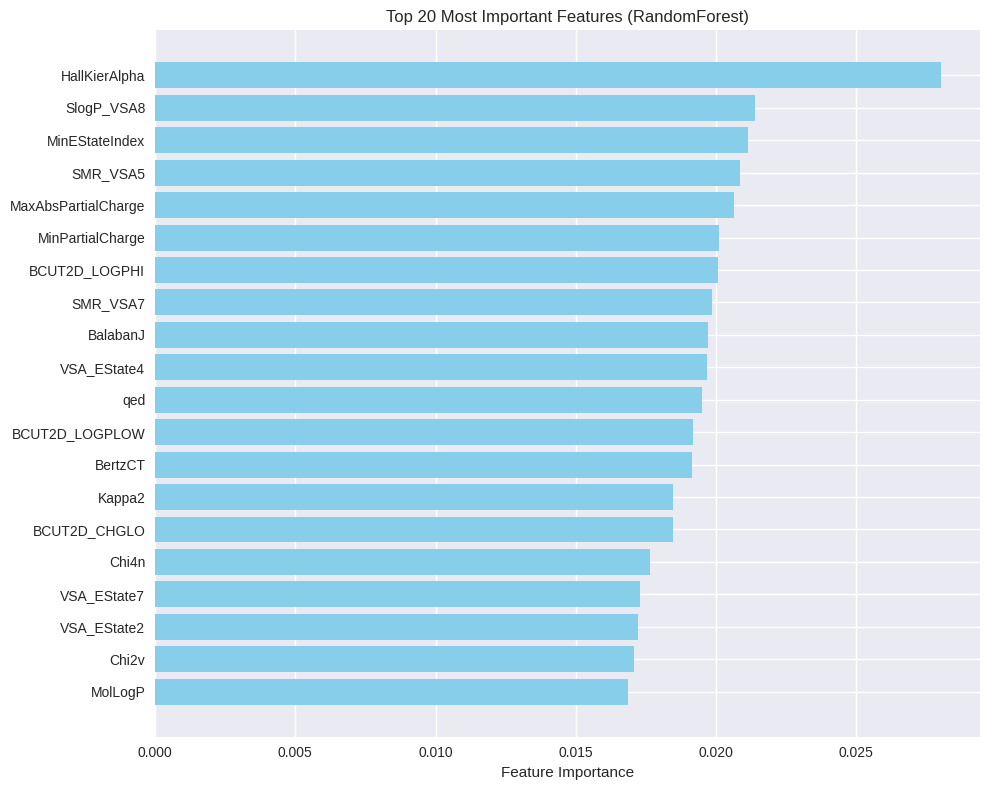

In [31]:
# 1. Extract the trained RandomForest model from SelectFromModel
rf_model = selector.estimator_

# 2. Get feature importances and names
importances = rf_model.feature_importances_
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"Feature {i}" for i in range(X_train.shape[1])]

# 3. Sort features by importance (descending) and select top 20
sorted_idx = np.argsort(importances)[::-1][:20]  # Indices of top 20 features
sorted_importances = importances[sorted_idx]
sorted_names = [feature_names[i] for i in sorted_idx]

# 4. Plot (horizontal bars)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), sorted_importances, align='center', color='skyblue')
plt.yticks(range(len(sorted_idx)), sorted_names)
plt.gca().invert_yaxis()  # Most important feature at the top
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features (RandomForest)')
plt.tight_layout()
plt.show()

### 6.1 Hyperparameter Tuning - Random Forest

In [32]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [4, 6],
    'max_features': ['sqrt', 0.3],
    'class_weight': [None, 'balanced'],
    'bootstrap': [True]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    verbose=1 # change for more info
)

grid_search.fit(X_train_selected, y_train)

# Show best parameters
print("Best parameters:")
print(grid_search.best_params_)

# %%
# Get best model
best_model = grid_search.best_estimator_

Fitting 10 folds for each of 144 candidates, totalling 1440 fits
Best parameters:
{'bootstrap': True, 'class_weight': None, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 200}


### 6.2 Hyperparameter Tuning - SVM

In [33]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}


grid_search_svm = GridSearchCV(
    estimator=SVC(probability=True, random_state=RANDOM_STATE),
    param_grid=param_grid_svm,
    scoring='f1',
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train_selected, y_train)
print("SVM Best Params:", grid_search_svm.best_params_)
best_model_svm = grid_search_svm.best_estimator_


Fitting 10 folds for each of 24 candidates, totalling 240 fits
SVM Best Params: {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}


### 7.1 Model Evaluation - Random Forest

Training Performance:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      2639
           1       0.95      0.97      0.96      3179

    accuracy                           0.96      5818
   macro avg       0.96      0.96      0.96      5818
weighted avg       0.96      0.96      0.96      5818


Test Performance:
[[528 132]
 [115 680]]
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       660
           1       0.84      0.86      0.85       795

    accuracy                           0.83      1455
   macro avg       0.83      0.83      0.83      1455
weighted avg       0.83      0.83      0.83      1455

ROC AUC: 0.897


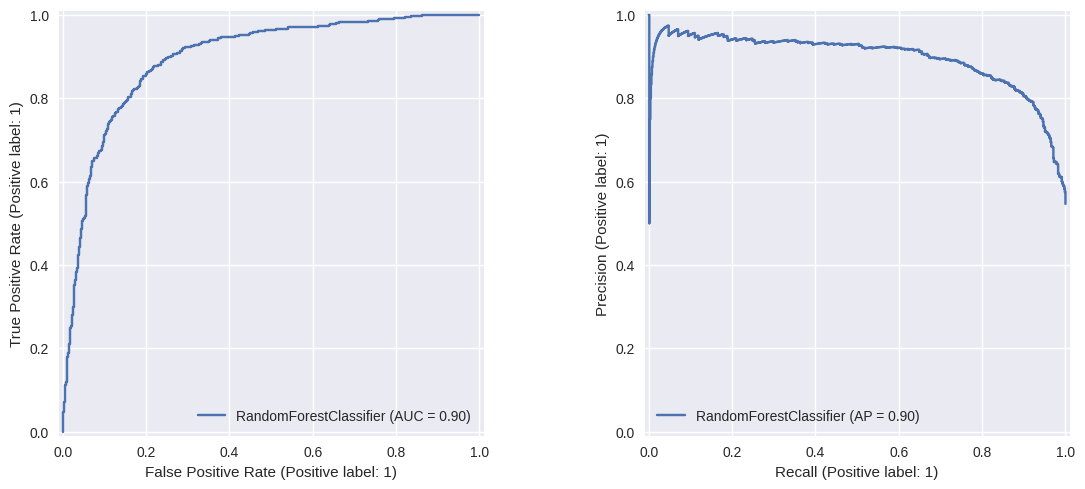

In [34]:
# Training evaluation
train_pred = best_model.predict(X_train_selected)
print("Training Performance:")
print(classification_report(y_train, train_pred))

# Test evaluation
test_pred = best_model.predict(X_test_selected)
test_proba = best_model.predict_proba(X_test_selected)[:, 1]

print("\nTest Performance:")
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred))
print(f"ROC AUC: {roc_auc_score(y_test, test_proba):.3f}")

# Plot curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_estimator(best_model, X_test_selected, y_test, ax=ax1)
PrecisionRecallDisplay.from_estimator(best_model, X_test_selected, y_test, ax=ax2)
plt.tight_layout()
plt.show()

### 7.2 Model Evaluation - SVM

Training Performance:
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      2639
           1       0.88      0.92      0.90      3179

    accuracy                           0.89      5818
   macro avg       0.89      0.89      0.89      5818
weighted avg       0.89      0.89      0.89      5818


Test Performance:
[[501 159]
 [113 682]]
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       660
           1       0.81      0.86      0.83       795

    accuracy                           0.81      1455
   macro avg       0.81      0.81      0.81      1455
weighted avg       0.81      0.81      0.81      1455

ROC AUC: 0.886


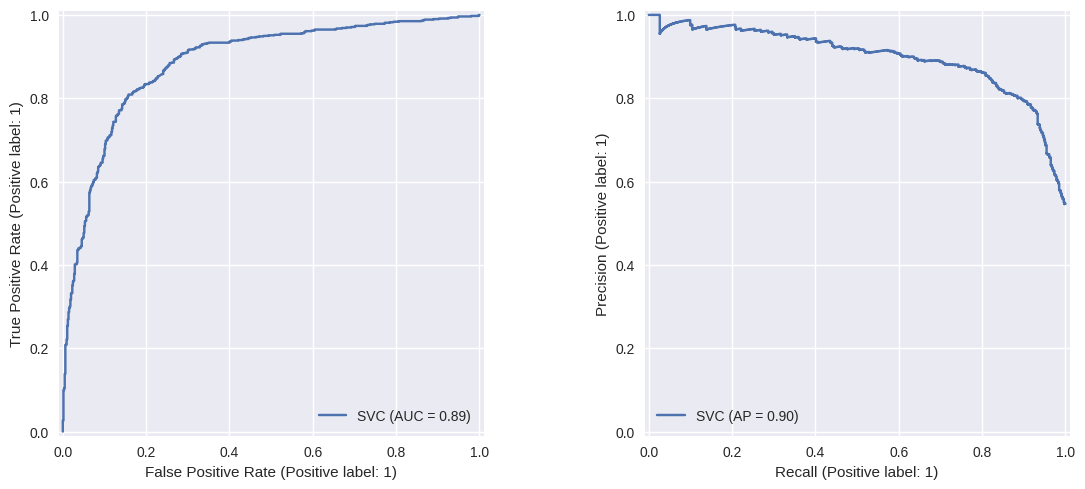

In [35]:
# Training evaluation
train_pred = best_model_svm.predict(X_train_selected)
print("Training Performance:")
print(classification_report(y_train, train_pred))

# Test evaluation
test_pred = best_model_svm.predict(X_test_selected)
test_proba = best_model_svm.predict_proba(X_test_selected)[:, 1]

print("\nTest Performance:")
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred))
print(f"ROC AUC: {roc_auc_score(y_test, test_proba):.3f}")

# Plot curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_estimator(best_model_svm, X_test_selected, y_test, ax=ax1)
PrecisionRecallDisplay.from_estimator(best_model_svm, X_test_selected, y_test, ax=ax2)
plt.tight_layout()
plt.show()

### 8. Feature Importance Analysis

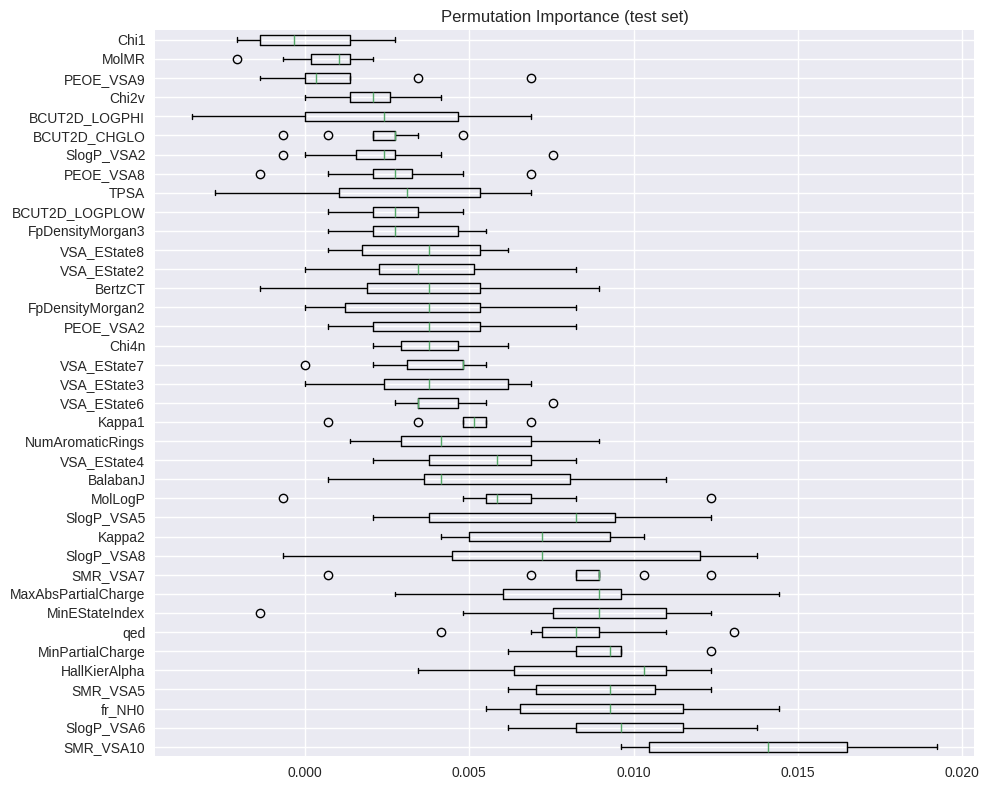

In [36]:
# Permutation importance
result = permutation_importance(
    best_model, X_test_selected, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
# Limit to top 50 important features
sorted_idx = result.importances_mean.argsort()[::-1]
plt.figure(figsize=(10, 8))
plt.boxplot(
    result.importances[sorted_idx[:50]].T,
    vert=False,
    tick_labels=np.array(X_train.columns[selector.get_support()])[sorted_idx[:50]]
)
plt.title("Permutation Importance (test set)")
plt.tight_layout()
plt.show()

## Description and Analysis of Supervised ML Pipeline

### 1. Data Loading and Preparation

This step loads the input data and ensures reproducibility. A fixed `RANDOM_STATE` is set for consistency across NumPy and scikit-learn operations. The dataset is split into two components: `X`, a matrix of 208 molecular descriptors derived from SMILES strings, and `y`, the binary mutagenicity label (1 = mutagenic, 0 = non-mutagenic), both loaded from preprocessed DataFrames.

An optional code block (commented out) allows synthetic data generation for pipeline testing, simulating the structure of the real dataset.

This step ensures clean and consistent input for downstream processing.


### 2. Exploratory Data Analysis

This step summarizes the dataset and highlights early patterns in class distribution and feature relevance. The feature matrix contains 7,273 compounds described by 208 molecular descriptors. The target variable is slightly imbalanced, with 54.6% labeled as mutagenic and 45.4% as non-mutagenic. A countplot visually confirms this.

To evaluate the relationship between features and mutagenicity, the ANOVA F-test is applied. It computes F-scores and p-values for each descriptor, indicating how well a feature discriminates between classes. Results are sorted by p-value to highlight the most significant features.

Top features—such as `SlogP_VSA8`, `NumAromaticRings`, and `fr_nitro`—exhibit extremely low p-values (e.g., < 1e-50), confirming strong relevance to mutagenicity. These insights inform downstream feature selection and model design.

#### **Falta contexto das features**

### 3. Train-Test Split and Univariate Feature Selection

To evaluate model performance on unseen data, the dataset is split into training and test sets using an 80/20 stratified split. Stratification ensures that the class distribution of mutagenic (1) and non-mutagenic (0) compounds remains consistent across both subsets. After splitting, the class proportions in the training and test sets are confirmed and shown to closely mirror the full dataset.

Following the split, univariate feature selection is applied using the ANOVA F-test, but importantly, this is done **only on the training data** to avoid data leakage. This statistical test evaluates each feature individually to determine how significantly its values differ between the two classes.

A mask is created to select only those features with p-values less than 0.01, which are considered statistically significant. This threshold helps reduce dimensionality while retaining the most relevant predictors. The same mask is then applied to the test data to ensure consistency. The process results in a reduced set of features that are more likely to contribute meaningfully to the classification task.

### 4. Feature Scaling

To prepare the feature data for machine learning models, especially those sensitive to feature scales (e.g., SVM, kNN, or logistic regression), standardization is applied using `StandardScaler`. This scaler transforms the data such that each feature has zero mean and unit variance.

The scaler is fit **only on the training set** to avoid data leakage and then applied to both the training and test sets. This ensures that the scaling is based solely on information available during model training. Although tree-based models like Random Forest do not require scaling, it is applied here to maintain compatibility with other possible models used later in the pipeline.

### 5. Feature Selection

In this step, a model-based feature selection method is applied using `SelectFromModel` with a Random Forest classifier. This technique evaluates the importance of each feature during model training and retains only those whose importance exceeds a given threshold—in this case, 1.5 times the median feature importance.

Out of the original 113 features remaining after univariate filtering, 38 features were selected. These retained features are considered to have the strongest influence on the classification decision, as judged by the Random Forest’s internal impurity-based importance scores.

To visualize the most influential variables, the top 20 features (based on their importance scores) are plotted. Features such as `HallKierAlpha`, `SlogP_VSA8`, and `MinEStateIndex` were among the most important, indicating that they strongly contribute to the model’s ability to distinguish between mutagenic and non-mutagenic compounds.

This method serves as a second, model-informed filter to reduce noise and dimensionality while retaining features that improve predictive performance.

#### **Falta contexto das features**

### 6. Hyperparameter Tuning

To optimize model performance, grid search with cross-validation was used to fine-tune the hyperparameters of both the Random Forest and Support Vector Machine (SVM) classifiers.

For the Random Forest model, a grid of hyperparameters was defined, including the number of estimators, tree depth, minimum samples per split and leaf, and options for class weighting and feature subsampling. The grid search was conducted using 10-fold stratified cross-validation and evaluated based on the F1 score, which balances precision and recall. The best combination of hyperparameters was selected and used to instantiate the final Random Forest model.

For SVM, a similar tuning procedure was applied. The parameter grid included different values of the regularization strength `C`, kernel types (`rbf` and `linear`), kernel scaling (`gamma`), and class weighting. SVM is sensitive to feature scales, so scaled features from the previous step were used. The best-performing configuration was selected using 10-fold stratified cross-validation, also optimized for F1 score.

This tuning step ensures that both models are trained with the best possible settings for the given data, maximizing their ability to generalize to unseen compounds.


### 7.1 Model Evaluation – Random Forest

The trained Random Forest model was evaluated on both the training and test sets. On the training data, the model achieved near-perfect results, with precision, recall, and F1-scores all above 0.95 for both classes. This indicates that the model fits the training data well, but also raises the possibility of overfitting.

On the test set, the model achieved an accuracy of 83%, with a precision of 84% and recall of 86% for the mutagenic class. The confusion matrix shows a balanced performance across both classes, with relatively low false positive and false negative rates.

The ROC curve demonstrates a high area under the curve (AUC = 0.897), indicating strong discriminative ability between the two classes. Similarly, the Precision-Recall curve shows high average precision (AP = 0.90), suggesting that the model maintains good precision across various recall thresholds.

These metrics confirm that the Random Forest model generalizes well to unseen data and effectively distinguishes between mutagenic and non-mutagenic compounds.


### 7.2 Model Evaluation – Support Vector Machine (SVM)

The performance of the SVM model, optimized through hyperparameter tuning, was evaluated on both the training and test sets. On the training data, the SVM achieved high classification metrics, with an accuracy of 89% and balanced F1-scores for both classes (0.87 for non-mutagenic and 0.90 for mutagenic). This indicates strong learning performance without clear signs of overfitting.

On the test set, the SVM achieved an accuracy of 81%. The F1-score for the mutagenic class was 0.83, with a precision of 81% and recall of 86%, showing good generalization and effectiveness at identifying mutagenic compounds.

The ROC curve shows an area under the curve (AUC) of 0.886, indicating strong discriminatory ability. The precision-recall curve further supports this, with an average precision (AP) of 0.90, reflecting consistent performance even under varying classification thresholds.

While slightly less accurate than the Random Forest model, the SVM still demonstrated solid generalization and high-quality classification on this high-dimensional chemical descriptor dataset.


### 8. Feature Importance Analysis

To interpret the model’s decision process and identify which molecular descriptors contributed most to the predictions, permutation importance was computed on the test set. This method assesses the impact of each feature by randomly shuffling its values and measuring the drop in model performance. Features that cause greater reductions in accuracy or F1 score when permuted are considered more important.

The analysis was repeated 10 times (`n_repeats=10`) to improve reliability. The top 50 features, ranked by their average permutation importance, were visualized using a boxplot. This plot captures the variability of each feature’s importance across multiple shuffles, highlighting the robustness and consistency of their contribution to the model.

Key features such as `SMR_VSA10`, `SlogP_VSA6`, `fr_NH0`, and `HallKierAlpha` showed the highest importance, confirming their critical role in mutagenicity classification. These features align closely with those previously identified by univariate tests and tree-based feature rankings, strengthening the confidence in their relevance.

Permutation importance offers a model-agnostic and intuitive explanation of the model’s behavior, making it a valuable final step in feature analysis.

#### **Falta contexto das features**